<a href="https://colab.research.google.com/github/robert-colley/PyBaMM/blob/main/OpusConvert_v1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install brukeropusreader

  Preparing metadata (setup.py) ... done
  Created wheel for brukeropusreader: filename=brukeropusreader-1.3.4-py3-none-any.whl size=5304 sha256=e4dcab8e6d3274f6438c57ffade74d12ce6381f9412ea59bd056079dfb52063f
  Stored in directory: /root/.cache/pip/wheels/50/2c/3f/76f26815f626765470c31864b7a3e993ae5617b399be506fe0
Successfully built brukeropusreader


In [ ]:
from datetime import datetime, time, timezone, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from google.colab import drive, files
from brukeropusreader import read_file
from matplotlib import rc
import pandas as pd
import math as m
import re
# drive.mount('/content/drive')

In [ ]:
import os
import shutil

def clean_colab_content(confirm=True, preserve_drive=True, preserve_csv=True):
    """
    Deletes all files and folders in /content/, except:
      - /content/drive (if mounted and preserve_drive=True)
      - any .csv files (if preserve_csv=True)

    Parameters:
        confirm (bool): Ask for confirmation before deleting.
        preserve_drive (bool): Skip /content/drive if True.
        preserve_csv (bool): Skip .csv files if True.
    """
    base_path = "/content/"
    drive_path = os.path.join(base_path, "drive")

    if confirm:
        answer = input(
            "⚠️  This will delete most files in /content/. "
            "Google Drive and .csv files will be preserved. Proceed? (y/n): "
        )
        if answer.lower() != 'y':
            print("❌ Cleanup canceled.")
            return

    deleted = []
    skipped = []

    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)

        # Skip drive mount if requested
        if preserve_drive and item_path.startswith(drive_path):
            skipped.append(item_path)
            continue

        # Skip .csv files if requested
        if preserve_csv and item.lower().endswith(".csv"):
            skipped.append(item_path)
            continue

        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
                deleted.append(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                deleted.append(item_path)
        except Exception as e:
            print(f"Error deleting {item_path}: {e}")

    print(f"✅ Cleanup complete.\n🗑️  Deleted: {len(deleted)} items\n⏭️  Skipped: {len(skipped)} items")
    if skipped:
        print("📁 Preserved files/directories:")
        for s in skipped:
            print(f"  - {s}")


In [ ]:
class OpusConvert():
  def __init__(self, key = "Sample"):
    self._root = "/content/"
    self.d = {}
    self.key = key
    self._ec_shift = 0

#___
  def rl(self,x):
    '''
    Helper function, range(len(x)), when used in for loop, returns indices of list or list-like objects.
    '''
    return range(len(x))

#___
  def roundFloatDown(self, number, decimalPlaces = 0):
    '''
    Helper function, rounds a floating point value down to a specified number of decimal places. Default is none
    Examples:
    roundFloatDown(2.57)    --> returns 2.0
    roundFloatDown(2.57, 1) --> returns 2.5
    roundFloatDown(2.57, 2) --> returns 2.57
    '''
    import math as m

    result = m.floor(number * 10 ** decimalPlaces)/(10**decimalPlaces)
    return result
#___


  def _parse_opus_dt(self, ab_params: dict) -> datetime:
      # get time from either TIM or TIME
      t = ab_params.get("TIM") or ab_params.get("TIME")
      if not t:
          raise KeyError("Neither 'TIM' nor 'TIME' present in AB Data Parameter.")
      # remove trailing ' (GMT-5)' or ' (GMT+2)' etc.
      t = re.sub(r"\s*\(GMT[+-]?\d+\)\s*$", "", t.strip())
      # build and parse
      dt_str = f"{ab_params['DAT']} {t}"
      return datetime.strptime(dt_str, "%d/%m/%Y %H:%M:%S.%f")

#___
  def trim_data(self):
    '''
    Automatically removes data artifact from OPUS.
    '''
    for i in self.rl(self.d):
      try:
        self.d[f"{self.key} {i}"]["AB"] = np.delete(self.d[f"{self.key} {i}"]["AB"], self.d[f"{self.key} {i}"]["AB Data Parameter"]["NPT"])

      except IndexError:
        pass

#___
  def x(self):
    self.x = np.linspace(self.d[f"{self.key} 0"]["AB Data Parameter"]["FXV"],self.d[f"{self.key} 0"]["AB Data Parameter"]["LXV"],self.d[f"{self.key} 0"]["AB Data Parameter"]["NPT"])
    anchor = 0
    for i in self.rl(self.d):
      fxv = self.d[f"{self.key} {i}"]["AB Data Parameter"]["FXV"]
      lxv = self.d[f"{self.key} {i}"]["AB Data Parameter"]["LXV"]
      npt = self.d[f"{self.key} {i}"]["AB Data Parameter"]["NPT"]
      comparator = np.linspace(fxv, lxv, npt)
      #adjusts all spectra so that they are the same length as the shortest dataset.
      if len(self.x) > len(comparator):
        for j in range(anchor, i):
          self.d[f"{self.key} {j}"]["AB"] = np.interp(comparator, self.x[::-1],self.d[f"{self.key} {j}"]["AB"][::-1])
        self.x = comparator
        anchor = i

      elif len(self.x) < len(comparator):
          self.d[f"{self.key} {i}"]["AB"] = np.interp(self.x, comparator[::-1], self.d[f"{self.key} {i}"]["AB"][::-1])


#___
  def read_files(self):

    self._fup = files.upload() # Select files to upload. Returns dict of files, filenames are keys.
    counter = 0

    if self.key == "Sample":
      for fn in self._fup.keys():
          self.d[f"{self.key} {counter}"] = read_file(f"/content/{fn}")
          counter += 1
    else:
      for fn in self._fup.keys():
          self.d[f"{self.key[counter]}"] = read_file(f"/content/{fn}")
          counter += 1
    self.trim_data()
    self.x()
#___
  def t_stamp(self):
    _prompt = input("Type the expt start point in EC-Lab time (seconds)\t")
    self.ec_shift = float(_prompt)  # note: you initially defined _ec_shift; be consistent.

    # origin time from the first record
    ogn = self._parse_opus_dt(self.d[f"{self.key} 0"]["AB Data Parameter"])

    # compute deltas for all records
    for k in list(self.d):
        cur = self._parse_opus_dt(self.d[k]["AB Data Parameter"])
        delta = (cur - ogn).total_seconds()
        self.d[k]["Timestamp"] = delta + self.ec_shift
#___
  def df(self):
    self.dfAB = pd.DataFrame({keys: self.d[keys]['AB'] for keys in self.d})
    self.dfA = self.dfAB.copy()
    self.dfAB.insert(0,"Wavenumbers/cm⁻¹",self.x)
    self.dfT = pd.DataFrame([self.d[keys]['Timestamp'] for keys in self.d], index = [keys for keys in self.d], columns = ["Timestamp (EC-Lab Time)"])
    self.dfA = self.dfA.set_axis(oc.dfT['Timestamp (EC-Lab Time)'].to_xarray(), axis = 1)
    self.dftir = self.dfA.T.set_axis(oc.dfAB["Wavenumbers/cm⁻¹"].to_xarray(),axis = 1)
#___
  def process(self):
    self.t_stamp()
    self.df()

#___
  def export(self):
    _out = input("Type Filename (No Spaces)\t")
    self.dfAB.to_csv(f"{self._root}{_out}_all.csv")
    self.dfT.to_csv(f"{self._root}{_out}_timestamped.csv")
    self.dftir.to_csv(f"{self._root}{_out}_tir.csv")


#___
  def perform_black_magic(self):
    self.read_files()
    self.process()
    self.export()

  def match_closest(self, timesToMatch, startingVoltage, endingVoltage, steps):
    '''
    search for closest timestamped values for a list of times which are to be matched.
    '''
    _matches = []
    arr1 = np.array(self.dfT['Timestamp (EC-Lab Time)'])
    for i in timesToMatch:
      condition = np.min(np.abs(arr1 - i))
      # Take target time, and deduct it from the timestamps for all spectra, find the absolute minimum in the array.

      for j in range(len(arr1)):
        #if the condition is met, print the sample name, timestamp, and how far it was from the target.
        if np.abs(arr1[j] - i) == condition:
          print(f"{self.dfT.iloc[j].name}:",f"{self.dfT.iloc[j]['Timestamp (EC-Lab Time)']}", f"\tdelta (time of measurement - targeted times):{round(arr1[j] - i, 4)}")

          #additionally append the name identifiers to a list named _matches, and convert to a trimmed DataFrame.
          _matches.append(self.dfT.iloc[j].name)


    self.dfSelected = self.dfAB[_matches]
    self.dfSelected.insert(0,"Wavenumbers/cm⁻¹",self.x)
    prompt = input("export selected samples? (y/n)\t")
    if prompt.lower() == "y":
      _out = input("Enter filename (no spaces)\t")
      self.dfSelected.to_csv(f"{self._root}/{_out}_selected.csv")

#___
  def matches_to_list(self, timesToMatch):
    _matches = []
    arr1 = np.array(self.dfT['Timestamp (EC-Lab Time)'])

    for i in timesToMatch:
      condition = np.min(np.abs(arr1 - i))

      for j in range(len(arr1)):
        #if the condition is met, append the name identifiers for matches to a list named _matches

        if np.abs(arr1[j] - i) == condition:
          _matches.append(self.dfT.iloc[j].name)
    #return the list as an object which can be used
    return _matches
#___
  def shiftCorrection(self, referencePoint = 0):
    for k in self.d.keys():
      self.d[k]["AB"] = self.d[k]["AB"] - self.d[k]["AB"][referencePoint]

#___ Take the SCsm value of selected sample (0 by default) and use it as a background for all other samples, FTIR uses a log(I0/I) comparison to produce absorption spectra.
  def rebase(self, background = "Sample 0"):
    newBkgd = background
    for i in self.d.keys():
      self.d[i]["AB"] = np.log(self.d[newBkgd]["ScSm"]/self.d[i]["ScSm"])
    self.process()#reprocesses the absorption dataframes

#___
  def import_references(self):
    self._ref_files = files.upload()
    for k in self._ref_files.keys():
      self.references = pd.read_excel(f"/content/{k}")
    return self.references

#___
  def import_LSV(self):
    self.LSV_files = files.upload()
    for k in self.LSV_files.keys():
      self.lsv = pd.read_excel(f"/content/{k}", header = [0,1])
    return self.lsv

#___
  def differentials(self, _background, backgroundLabel, samples, labels):
    '''
    Generates differential spectra from a specified background sample. Creates a
    background attribute in the OpusConvert object, and a dDiff attribute, which
    is a dictionary holding the differential values
    '''
    self.background = self.d[_background]["AB"]
    self.dDiff = {}

    for i, n in enumerate(samples):
      self.dDiff[f"{labels[i]}"] = self.d[n]["AB"] - self.background

    self.dfDiff = pd.DataFrame({f"{k} - {backgroundLabel}": self.dDiff[k] for k in self.dDiff.keys()})
    self.dfDiff.insert(0, f"{backgroundLabel}", self.background)
    self.dfDiff.insert(0, "Wavenumbers/cm⁻¹", self.x)
    return self.dDiff
#___
  def plot_differentials(self, _background, ttl, ax = None, _xlim = (2500,600),_offset = 0.01 , _lw = 0.5, _color = "r",_w = 7.75, _h = 6.77, _dpi = 100, _xytext = (50,0)):
    if ax == None:
      fig, ax = plt.subplots(figsize = (_w, _h), dpi = _dpi)

    for i, k in enumerate(self.dDiff.keys()):
      _y = oc.dDiff[k]-oc.dDiff[k][0] + i * _offset
      ax.plot(oc.x, _y, linewidth = _lw, color = _color)
      ax.annotate(
      f"{k} - {_background}",
      xy=(oc.x[len(oc.x)-100], _y[len(oc.x)-100]),
      xytext= _xytext,
      textcoords="offset points")


    ax.set_xlim(*_xlim)
    ax.set_xlabel("Wavenumbers (cm⁻¹)")
    ax.set_ylabel("absorbance units (a.u.)")
    ax.set_yticks([])
    ax.set_title(ttl)

    return ax
#___
  # def plot_LSV(self,)
#___
  def gen_steps(self, vI,vF):
    result = int((vI-vF)*10)+1
    if result > 0:
      return result
    else:
      result *= -1
      result += 2
      return result
#___
  def gen_labels(self, vI, vF):
    result = int((vI-vF)*10)+1
    if result > 0:
      return [f"{round(i,2)}V" for i in np.linspace(vI, vF, result)]
    else:
      result *= -1
      return [f"{round(i,2)}V" for i in np.linspace(vI, vF, result + 2)]


In [ ]:
#PRESET CONFIGURATIONS AND VLINE PLOTTING
def preset_format(ax, *, axislabelfontsize = 8, title=None, xlabel=None, ylabel=None,
                       xlim=None, ylim=None, linewidth = None, yticksoff = True, grid=False,
                  minor_grid=False, legend=False):
    # Titles / labels
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize = axislabelfontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad = 0, fontsize = axislabelfontsize)
        ax.yaxis.set_label_position("left")

    # Limits
    if xlim is not None:
        ax.set_xlim(*xlim) if isinstance(xlim, (list, tuple)) else ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(*ylim) if isinstance(ylim, (list, tuple)) else ax.set_ylim(ylim)

    # Linewidth
    if linewidth is not None:
        for lines in ax.lines:
            lines.set_linewidth(linewidth)

    # Spines (a common “clean” look)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    # Ticks
    ax.tick_params(direction="in", length=2, width=0.5)
    ax.tick_params(which="minor", length=2)
    ax.tick_params(axis = "x", labelsize = 6)
    ax.tick_params(axis = "y", labelsize = 6)
    ax.yaxis.set_ticks_position("both")
    ax.xaxis.set_ticks_position("both")

    if yticksoff:
        ax.set_yticklabels([])
    # Minor ticks (nice for scientific plots)
    ax.minorticks_off()

    # Grid
    if grid:
        ax.grid(True, which="major", alpha=0.25)
    if minor_grid:
        ax.grid(True, which="minor", alpha=0.10)

    # Example formatter: avoid too many decimals by default
    # ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    # ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    # Legend (only if there are labeled artists)
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(frameon=False, fontsize = 6)

    return ax  # returning ax is convenient for chaining

def vline(ax, x, precision, x_ref, c = "black", a = 0.2, fs = 8, unit = "V",
          offset = (0,0), lw = 0.2, anchorY = None):
  for i, value in enumerate(x_ref):
    if abs(x-round(value, precision)) <= 1*10**(-precision):
      if anchorY is not None:
        ax.plot([x,x], [anchorY[0], anchorY[1]], color = c,
              alpha = a, linewidth = lw)
        if precision == 0:
          ax.annotate(f"{x}{unit}", xy = (x,anchorY[1]), xytext = offset,
                  textcoords = "offset points", fontsize = fs)
        else:
          ax.annotate(f"{round(x, precision)}{unit}", xy = (value,anchorY[1]), xytext = offset,
                  textcoords = "offset points", fontsize = fs)
      else:
        ax.plot([value,value], [ax.get_ylim()[0], ax.get_ylim()[1]], color = c,
              alpha = a, linewidth = lw)
        ax.annotate(f"{round(value, precision)}{unit}", xy = (value,ax.get_ylim()[1]), xytext = offset,
                  textcoords = "offset points", fontsize = fs)
      break
  return ax

In [ ]:
def normalize_values(y):
  result = (y - min(y))/(max(y)-min(y))
  return result

def ballpark_scale(reference, normalizedY):
  result = normalizedY * (max(reference) - min(reference))
  return result

def set_background(background_label, background):
  return background_label, background

def shift_to_origin(input_numpy_array, shift_index = 0):
  return input_numpy_array - input_numpy_array[shift_index]

def gen_labels(vI, vF):
  result = int((vI-vF)*10)+1
  if result > 0:
    return [f"{round(i,2)}V" for i in np.linspace(vI, vF, result)]
  else:
    result *= -1
    return [f"{round(i,2)}V" for i in np.linspace(vI, vF, result + 2)]

def calculate_differentials(dictionary_of_original_spectra, labels_for_differential_spectra, background_spectrum, background_label):
  dictionary_of_differential_spectra = {}
  for i, k in enumerate(dictionary_of_original_spectra):
    result = dictionary_of_original_spectra[k] - background_spectrum
    # dictionary_of_differential_spectra[f"{labels_for_differential_spectra[i]} - {background_label}"] = shift_to_origin(result)
    dictionary_of_differential_spectra[f"{labels_for_differential_spectra[i]}"] = shift_to_origin(result)

  return dictionary_of_differential_spectra


In [ ]:
oc = OpusConvert()
oc.read_files()
oc.process()

Saving 260317-Ge-0308FollowUp-65deg_256scans.0 to 260317-Ge-0308FollowUp-65deg_256scans.0
Saving 260317-Ge-0308FollowUp-65deg_256scans.1 to 260317-Ge-0308FollowUp-65deg_256scans.1
Saving 260317-Ge-0308FollowUp-65deg_256scans.2 to 260317-Ge-0308FollowUp-65deg_256scans.2
Saving 260317-Ge-0308FollowUp-65deg_256scans.3 to 260317-Ge-0308FollowUp-65deg_256scans.3
Saving 260317-Ge-0308FollowUp-65deg_256scans.4 to 260317-Ge-0308FollowUp-65deg_256scans.4
Saving 260317-Ge-0308FollowUp-65deg_256scans.5 to 260317-Ge-0308FollowUp-65deg_256scans.5
Saving 260317-Ge-0308FollowUp-65deg_256scans.6 to 260317-Ge-0308FollowUp-65deg_256scans.6
Saving 260317-Ge-0308FollowUp-65deg_256scans.7 to 260317-Ge-0308FollowUp-65deg_256scans.7
Saving 260317-Ge-0308FollowUp-65deg_256scans.8 to 260317-Ge-0308FollowUp-65deg_256scans.8
Saving 260317-Ge-0308FollowUp-65deg_256scans.9 to 260317-Ge-0308FollowUp-65deg_256scans.9
Saving 260317-Ge-0308FollowUp-65deg_256scans.10 to 260317-Ge-0308FollowUp-65deg_256scans.10
Saving 2

In [ ]:
oc.export()

Type Filename (No Spaces)	260317-Ge-0308FollowUp-65deg_256scans


In [ ]:
clean_colab_content()

⚠️  This will delete most files in /content/. Google Drive and .csv files will be preserved. Proceed? (y/n): y
✅ Cleanup complete.
🗑️  Deleted: 96 items
⏭️  Skipped: 4 items
📁 Preserved files/directories:
  - /content/260317-Ge-0308FollowUp-65deg_256scans_timestamped.csv
  - /content/260317-Ge-0308FollowUp-65deg_256scans_all.csv
  - /content/260317-Ge-0308FollowUp-65deg_256scans_tir.csv
  - /content/drive


In [ ]:
#File Upload for LSV data (Wide Format)
# fLSV = files.upload()
filepath1 = "/content/LSV_I-V-0318-NaFSICDEC.xlsx"
lsvs = pd.read_excel(f'/content/{[i for i in fLSV.keys()][0]}')
lsvs.dropna(axis = 0, how = "all", inplace = True)

lsv_dict = {}
set_selector = 0
for i, k in enumerate(lsvs):
  if "Ewe/V" in str(k):
    set_selector += 1
    lsv_dict[f"LSV {set_selector}.1"] = []
  lsv_dict[f"LSV {set_selector}.1"].append(k)

lsv1p1x = lsvs[lsv_dict["LSV 1.1"][0]]
lsv1p1y = lsvs[lsv_dict["LSV 1.1"][1]]

lsv1p2x = lsvs[lsv_dict["LSV 2.1"][0]]
lsv1p2y = lsvs[lsv_dict["LSV 2.1"][1]]

lsv2p1x = lsvs[lsv_dict["LSV 3.1"][0]]
lsv2p1y = lsvs[lsv_dict["LSV 3.1"][1]]

In [ ]:
lsv1p1x.dropna(axis = 0, how = "all", inplace = True)
lsv1p1y.dropna(axis = 0, how = "all", inplace = True)
lsv2p1x.dropna(axis = 0, how = "all", inplace = True)
lsv2p1y.dropna(axis = 0, how = "all", inplace = True)


In [ ]:
#File upload for E vs t (stacked format)
# fCA = files.upload()
filepath2 = "/content/260312-CA_Ewe_vs_t (1).xlsx"
dfCA = pd.read_excel(filepath2) #DATAFRAME
dCA = {} #DICTIONARY
dCA["t"] = dfCA[dfCA.columns[0]].to_numpy() #ARRAYS IN DICTIONARY - 0 position == LABEL
dCA["V"] = dfCA[dfCA.columns[1]].to_numpy() #ARRAYS IN DICTIONARY - 0 position == LABEL

In [ ]:
#File upload for References (Wide Format)
fRefs = files.upload()
filepath3 = "/content/260226-REFERENCES.xlsx"
dfRef = pd.read_excel(filepath3) #DATAFRAME

#Packing into dictionaries
dRef = {} #DICTIONARY
set_selector = -1
for i, k in enumerate(dfRef):
  if "Wavenumbers" in str(k):
    set_selector += 1
    dRef[f"Reference Set {set_selector}"] = []
  dRef[f"Reference Set {set_selector}"].append(k)

Saving 260226-REFERENCES.xlsx to 260226-REFERENCES.xlsx


In [ ]:
#Synchronization of EC Lab to FTIR
ca1 = [i for i in np.linspace(3271.6, 14870.1, oc.gen_steps(2.4,-0.5))] #LSV1.1
ca2 = [26792.5]+[i for i in np.linspace(27194.7,38398.0, oc.gen_steps(2.3,-0.5))] #LSV2.1
# ca3 = [i for i in np.linspace(7186.02,10785.9, 16)] #0.3V
# ca4 = [i for i in np.linspace(10944,14544.7, 16)]   #0.2V
# ca5 = [i for i in np.linspace(14704,18304, 16)]     #0.1V
# ca6 = [i for i in np.linspace(18467,22067, 16)]     #0V
# ca7 = [i for i in np.linspace(22231,25830, 16)]     #-0.1V

lDiffSpectraKeys = oc.matches_to_list(np.array(ca1+ca2))

#Manual Checks for Spectra identifiers
# oc.match_closest(np.array([i for i in np.linspace(3266.25,5065.27, 16)]), 1, 1, 1)
oc.match_closest(np.array([2909.43]+ca1+ca2), 1, 1, 1)
# oc.match_closest(np.array(ca2+ca3+ca4+ca5+ca6+ca7), 1, 1, 1)
# oc.match_closest(np.array(ca3+ca4+ca5+ca6+ca7), 1, 1, 1)
# oc.match_closest(np.array(ca4+ca5+ca6+ca7), 1, 1, 1)
# oc.match_closest(np.array(ca5+ca6+ca7), 1, 1, 1)
# oc.match_closest(np.array(ca6+ca7), 1, 1, 1)
# oc.match_closest(np.array(ca7), 1, 1, 1)

In [ ]:
sBackgroundLabel, arrBackgroundSpectrum = set_background("t0", oc.d["Sample 0"]["AB"])
# lDiffSpectraLabels = gen_labels(2.4,-0.5) + ["LSV 2.1 @2.38V"]+[f"LSV 2.1 {i}" for i in gen_labels(2.3,-0.5)]
# lDiffSpectraLabels = [f"CA {i+1}.{j+1}" for i in range(7) for j in range(16)]
lDiffSpectraLabels = [f"{round(oc.d[k]["Timestamp"]/3600,1)}h" for k in oc.d.keys()]
# dSelectedRawSpectra = {f"{k}": oc.d[k]["AB"] for k in lDiffSpectraKeys}
dSelectedRawSpectra = {f"{k}": oc.d[k]["AB"] for k in oc.d.keys()} #all the spectra

dDiffSpectra = calculate_differentials(dSelectedRawSpectra, lDiffSpectraLabels, arrBackgroundSpectrum, sBackgroundLabel)

#FORMATTING DIFFERENTIALS FOR PLOTTING
def label_plus_values(input_dictionary):
  reformatted_dictionary = {}
  reformatted_dictionary["Labels"] = [k for k in input_dictionary]
  reformatted_dictionary["Spectra"] = [input_dictionary[k] for k in input_dictionary]
  return reformatted_dictionary

dDiffSpectra = label_plus_values(dDiffSpectra)

In [ ]:
dfRefSet

,Na2CO3,DEC,EC,NaFSI (Drop Cast in DME)
0,0.055159,0.013083,0.003750,0.008029
1,0.055433,0.012700,0.003922,0.008204
2,0.055621,0.012448,0.004214,0.008130
3,0.055654,0.012509,0.004247,0.008024
4,0.055622,0.012712,0.003968,0.007996
...,...,...,...,...
2381,0.050579,0.011841,0.010363,0.004229
2382,0.051356,0.011683,0.010527,0.004785
2383,0.050809,0.011237,0.010743,0.006007
2384,0.049189,0.010758,0.010486,0.007437


In [ ]:
dfRefSet = pd.DataFrame(dfRef[dRef["Reference Set 0"][1:7]]) #SUBSELECTION OF REFERENCES
dfRefSet.dropna(axis = 0, how = "all", inplace = True) #GET RID OF NANS
dfRefSet.drop(columns = ["EC:DEC (1:1 n:n) - Remeasure", "EC:DEC (1:1 n:n)"], inplace = True) #FURTHER PRUNING OF DATAFRAME
# dfRefSet #LAST CHECK

In [ ]:
# dDiffSpectra["Labels"]

NameError: name 'lsv1p1x' is not defined

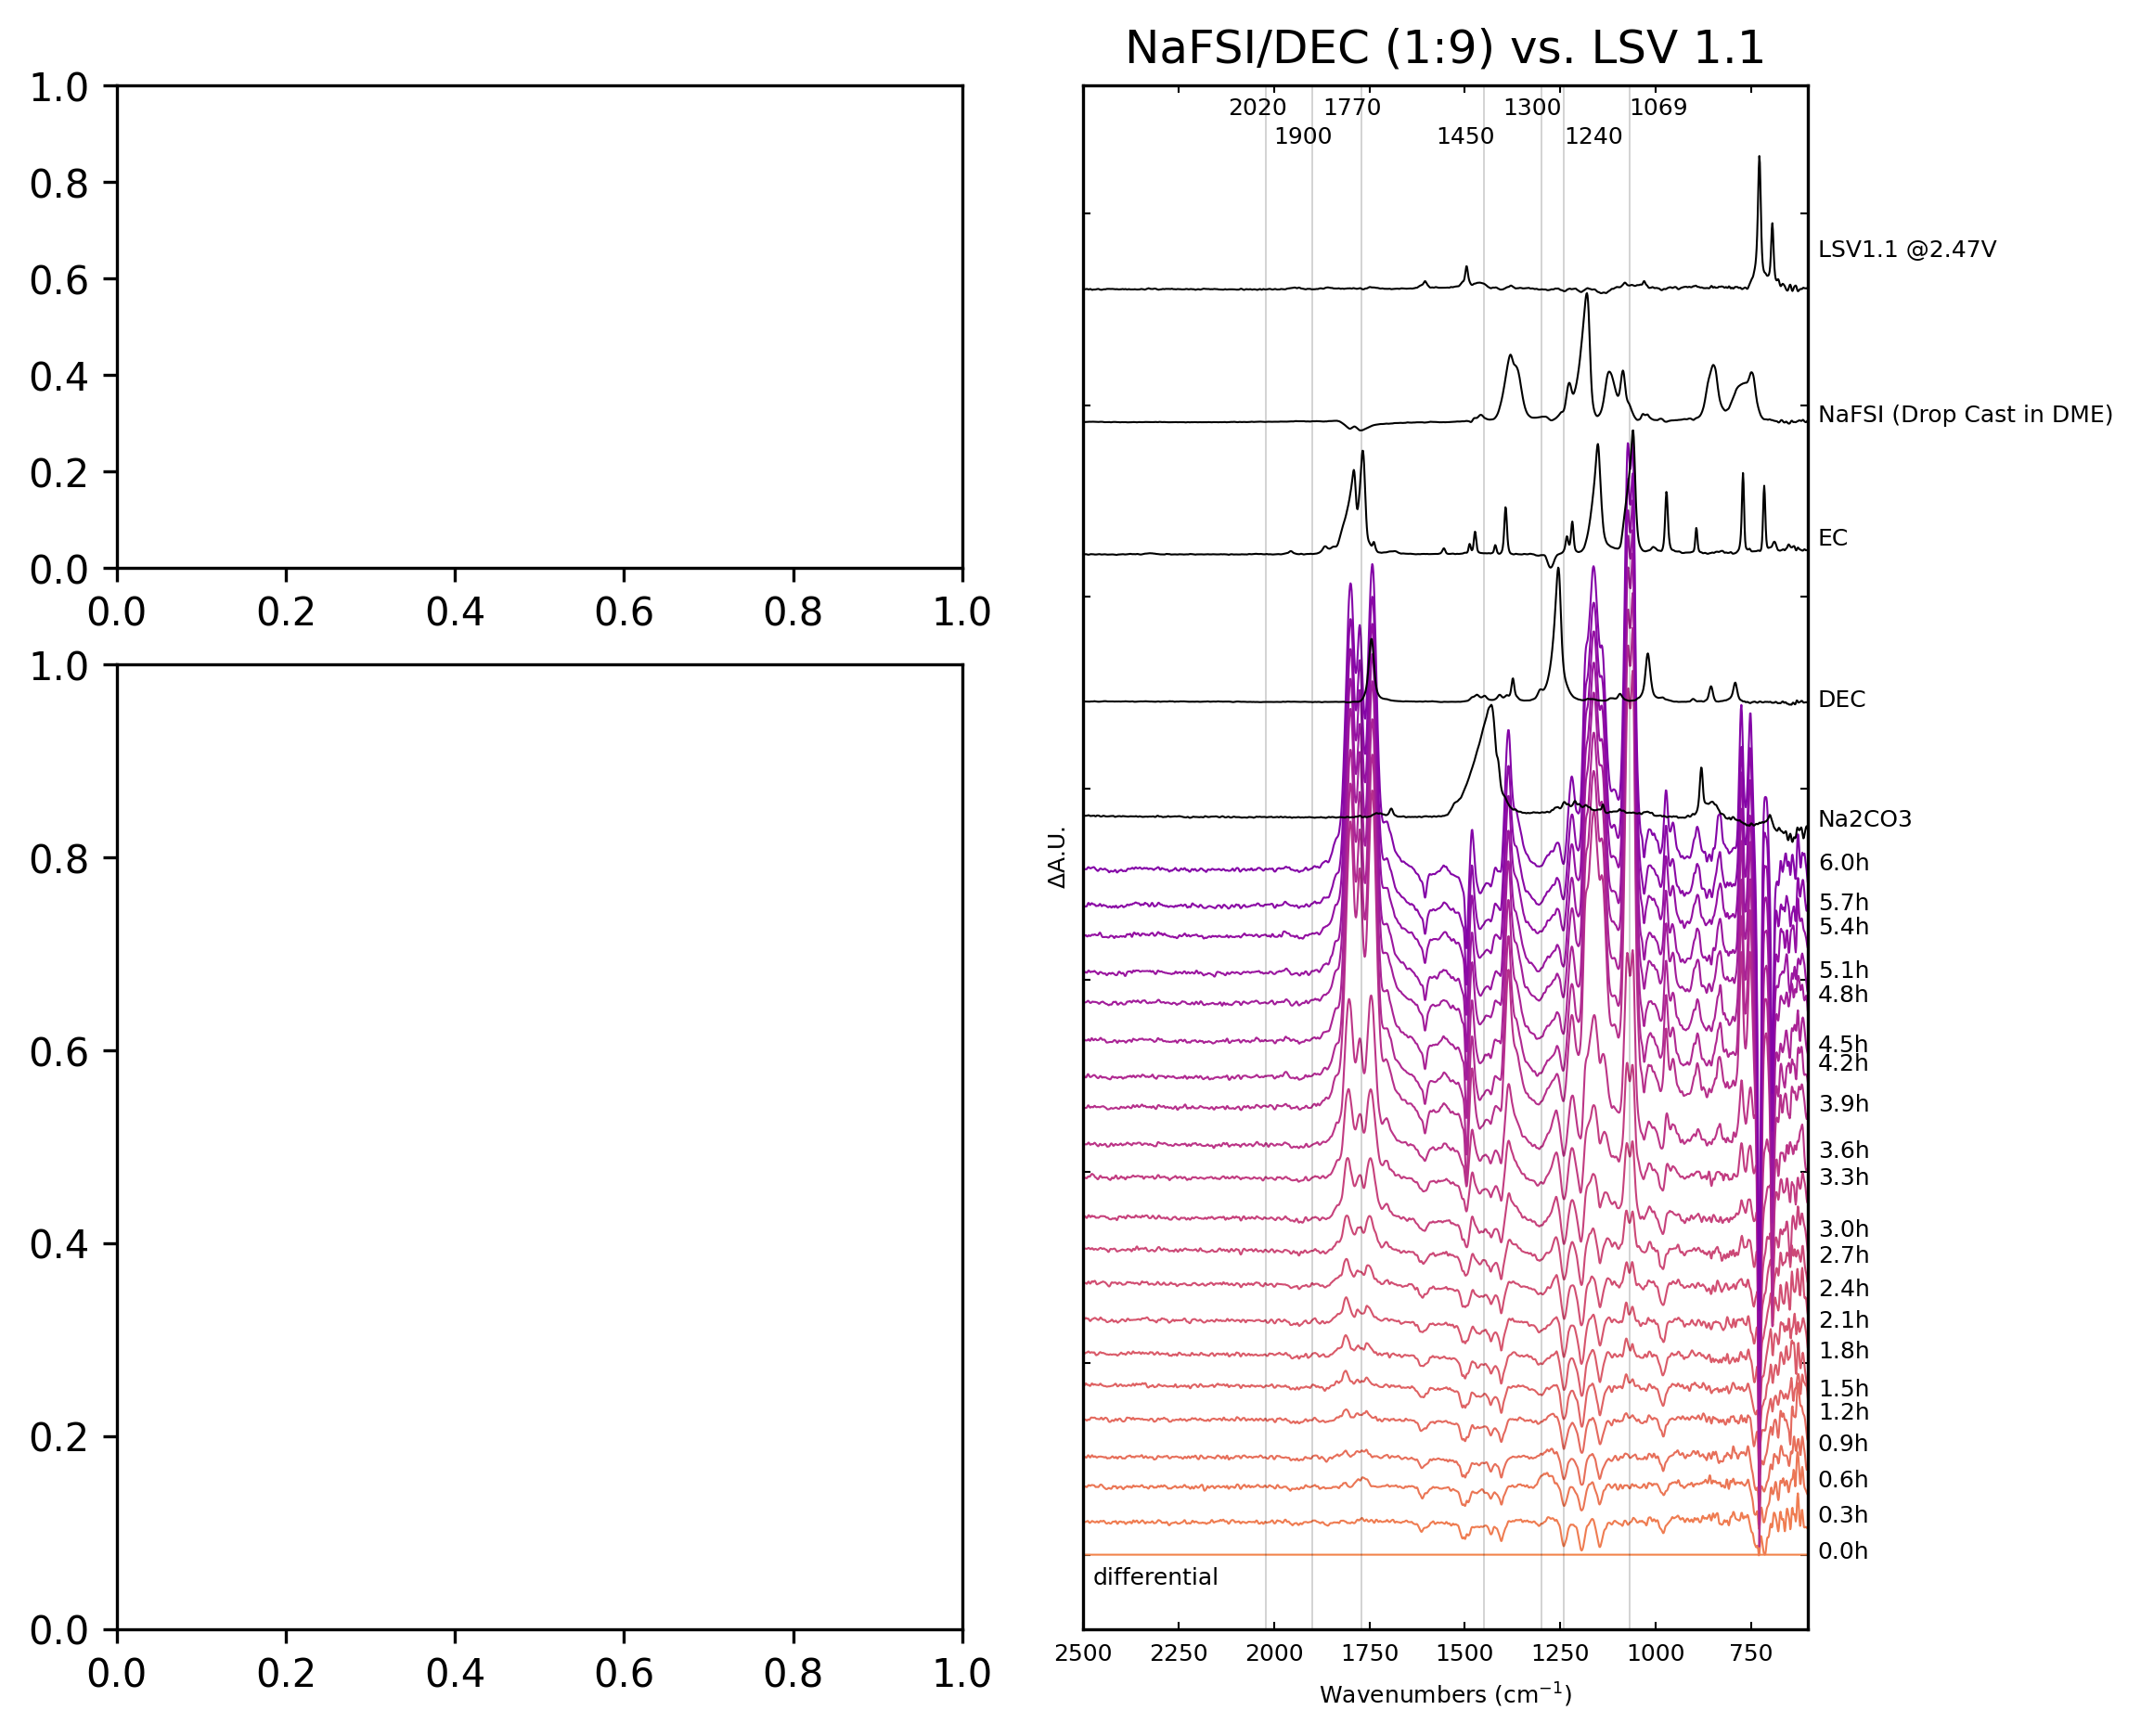

In [ ]:
'''PLOTTING PARAMETERS - 3 PANEL ELECTROCHEMICAL EXPT'''
plot_spacing = 0.003 #AX1
reference_stretching_factor = 2 #AX1
reference_spacing_factor = 1 #AX1
cmap = plt.cm.plasma #AX1 AND AX3
colors = cmap(np.linspace(0.7,0,len(["Two more elements", "to pad the list"]+lDiffSpectraLabels))).tolist()
c_index = 0
step = 3

x_left_bound = 2500
x_right_bound = 600
lw = 0.5
line_font_size = 6
annotation_font_size = 6
axis_label_font_size = 6

fig = plt.figure(figsize = (8.68, 6.93), dpi = 300)
ax1 = fig.add_axes([0.5, 0.1, 0.3, 0.8])
ax2 = fig.add_axes([0.1, 0.1, 0.35, 0.5])
ax3 = fig.add_axes([0.1, 0.65, 0.35, 0.25])

'''AX1 PLOTTING'''
'''DIFFERENTIALS'''
for i, y in enumerate(dDiffSpectra["Spectra"]):
  if i in [step*j for j in range(len(dDiffSpectra["Spectra"]))]:
    ax1.plot(oc.x, y + plot_spacing * i, color = colors[i])
    ax1.annotate(dDiffSpectra["Labels"][i], xy=(x_right_bound,
                  y[len(y)-50] + plot_spacing * i), xytext = [2.5, -1],
                textcoords = "offset points", fontsize = line_font_size)

'''REFERENCES'''
_ocv_index = 0
for i, y in enumerate(dfRefSet):
  _y = dfRef[y].to_numpy()
  _y = reference_stretching_factor * ballpark_scale(dDiffSpectra["Spectra"][5], normalize_values(_y))
  _x = dfRef[dRef["Reference Set 0"][0]].to_numpy()
  spacer = i * (reference_spacing_factor * ballpark_scale(_y, 1)) + plot_spacing * (len(dDiffSpectra["Spectra"]))
  ax1.plot(_x, _y + spacer, color = "black")
  ax1.annotate(f"{y}", xy = (x_right_bound, _y[2300] + spacer),
               xytext = [2.5,-1], textcoords = "offset points", fontsize = line_font_size)
  _ocv_index += 1

y_OCV = shift_to_origin(arrBackgroundSpectrum) #Set to common origin
y_OCV = normalize_values(y_OCV) #normalize to 0 1 scale
y_OCV = reference_stretching_factor* ballpark_scale(dDiffSpectra["Spectra"][5], y_OCV) #now rescale to some random spectrum, and apply any manual tweaks
ocv_spacer = _ocv_index * (reference_spacing_factor * ballpark_scale(y_OCV, 1)) + plot_spacing * (len(dDiffSpectra["Spectra"])) #finally, offset by same algorithm as the references for loop
y_OCV = y_OCV + ocv_spacer

ax1.plot(oc.x ,y_OCV, color = "black")
ax1.annotate("LSV1.1 @2.47V", xy = (x_right_bound, y_OCV[2300]),
             xytext = [2.5,-1], textcoords = "offset points", fontsize = line_font_size)

'''FINE FORMATTING FOR AX1'''
preset_format(ax1, axislabelfontsize = axis_label_font_size,
              xlabel = "Wavenumbers (cm$^{-1}$)", ylabel = r"$\Delta$A.U.",
              title = "NaFSI/DEC (1:9) vs. LSV 1.1",
              xlim = (x_left_bound, x_right_bound),
              ylim = (ax1.get_ylim()[0]+0.001, ax1.get_ylim()[1]),
              linewidth = lw)

'''LABELING OF PLOT TYPE AND ANALYSIS FOR AX1'''
ax1.annotate("differential", xy = (x_left_bound, dDiffSpectra["Spectra"][0][0]),
             xytext = (2.5,-7.5), textcoords = "offset points", fontsize = annotation_font_size)
_anchorY = ax1.get_ylim()
vline(ax1, 2020, 0, oc.x, fs = 6, offset = (-10,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1900, 0, oc.x, fs = 6, offset = (-10,-15), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1770, 0, oc.x, fs = 6, offset = (-10,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1450, 0, oc.x, fs = 6, offset = (-12.5,-15), unit = "", anchorY = _anchorY, lw = 0.4)
# vline(ax1, 1400, 0, oc.x, fs = 6, offset = (-12.5,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1300, 0, oc.x, fs = 6, offset = (-10,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1240, 0, oc.x, fs = 6, offset = (0,-15), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1069, 0, oc.x, fs = 6, offset = (0,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)

'''AX2 PLOTTING'''
'''LSVs'''
ax2.plot(lsv1p1x, lsv1p1y, label = "LSV 1.1")
ax2.plot(lsv2p1x, lsv2p1y, label = "LSV 2.1")


'''FINE FORMATTING FOR AX2'''
preset_format(ax2, axislabelfontsize = axis_label_font_size,
              xlabel = r"E vs. V$_{Na^{+}/Na^{0}}$", ylabel = r"I ($\mu$A)",
              ylim = (-30,10),
              yticksoff = False, legend = True, linewidth = lw)

'''ANALYSIS FOR AX2'''
_AnchorY2 = ax2.get_ylim()
vline(ax2, 1.8, 2, lsv1p1x, fs = 6, offset = (0,-10), anchorY = _AnchorY2)
vline(ax2, 1.25, 2, lsv1p1x, fs = 6, offset = (-10,-10), anchorY = _AnchorY2)
vline(ax2, 0.8, 2, lsv1p1x, fs = 6, offset = (0,-10), anchorY = _AnchorY2)
vline(ax2, 0.4, 2, lsv1p1x, fs = 6, offset = (0,-10), anchorY = _AnchorY2)
vline(ax2, -0.1, 2, lsv1p1x, fs = 6, offset = (-0,-10), anchorY = _AnchorY2)
vline(ax2, -0.35, 2, lsv1p1x, fs = 6, offset = (-15,-10), anchorY = _AnchorY2)

'''AX3 PLOTTING'''
'''RAW SPECTRA'''
for i, k in enumerate(oc.d):
  if k in ["Sample 23"]+ lDiffSpectraKeys:
    ax3.plot(oc.x, shift_to_origin(oc.d[k]["AB"],1000), color = colors[c_index])
    c_index += 1

'''FINE FORMATTING FOR AX3'''
preset_format(ax3, axislabelfontsize=axis_label_font_size,
              xlabel = "Wavenumbers (cm$^{-1}$)",
              ylabel = "Absorbance Units (A.U.)",
              xlim = (x_left_bound, x_right_bound),
              # ylim = (-0.025,0.025),
              linewidth = lw)
'''LABELING OF PLOT TYPE AND ANALYSIS FOR AX3'''
ax3.annotate("raw", xy = (x_left_bound, ax3.get_ylim()[1]),
             xytext = (2.5, -6), textcoords = "offset points", fontsize = annotation_font_size)
_anchorY3 = ax3.get_ylim()
vline(ax3, 2020, 0, oc.x, fs = 6, offset = (-10,-5.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1900, 0, oc.x, fs = 6, offset = (-15,-12.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1770, 0, oc.x, fs = 6, offset = (-10,-5.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1450, 0, oc.x, fs = 6, offset = (-12.5,-11.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
# vline(ax3, 1400, 0, oc.x, fs = 6, offset = (-12.5,-5.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1300, 0, oc.x, fs = 6, offset = (-10,-5.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1240, 0, oc.x, fs = 6, offset = (0,-12.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)
vline(ax3, 1069, 0, oc.x, fs = 6, offset = (0,-5.5+2), unit = "", anchorY = _anchorY3, lw = 0.4)

###___ SHOW PLOT AND SAVE
plt.show()

fig.savefig("/content/260318-1-LSV1p1_2p1-NaFSI_DEC_1_9.png")

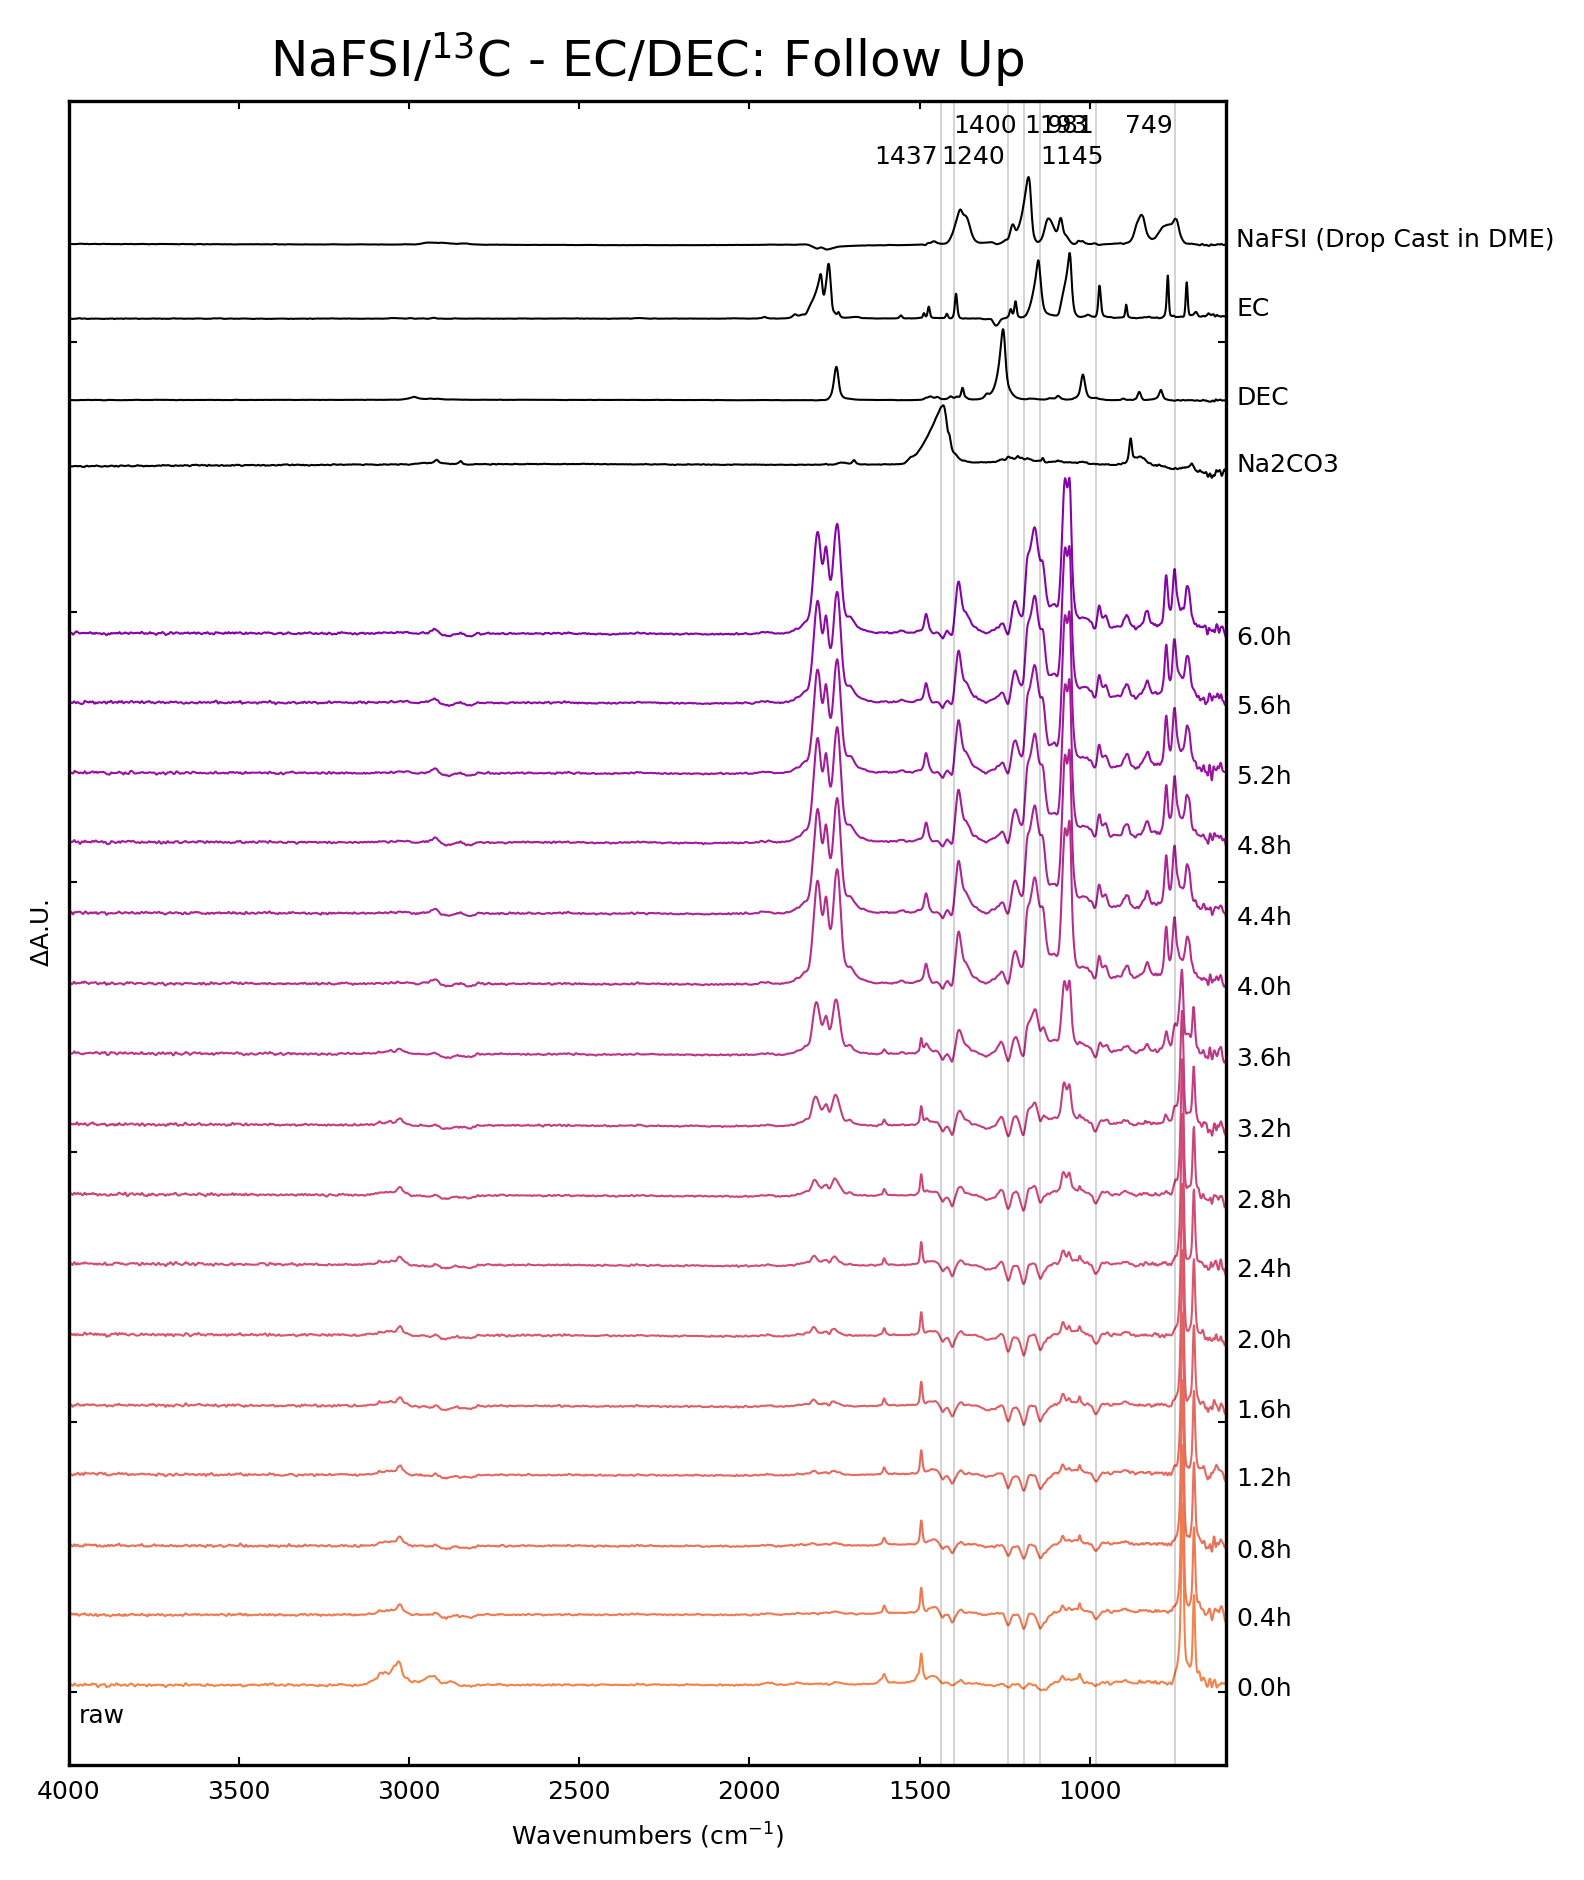

In [ ]:
'''PLOTTING PARAMETERS - EX-SITU EXPT'''
plot_spacing = 0.013 #AX1
reference_stretching_factor = 3 #AX1
reference_spacing_factor = 1.05 #AX1
cmap = plt.cm.plasma #AX1 AND AX3
colors = cmap(np.linspace(0.7,0,len(["Two more elements", "to pad the list"]+lDiffSpectraLabels))).tolist()
c_index = 0
step = 4

x_left_bound = 4000
x_right_bound = 600
lw = 0.5
line_font_size = 6
annotation_font_size = 6
axis_label_font_size = 6

fig = plt.figure(figsize = (8.68/1.8, 6.93), dpi = 300)
ax1 = fig.add_axes([0.05, 0.1, 0.8, 0.8])

'''AX1 PLOTTING'''
'''DIFFERENTIALS'''
prev = 0
for i, y in enumerate(dDiffSpectra["Spectra"]):
  if i in [step*j for j in range(len(dDiffSpectra["Spectra"]))]:
    ax1.plot(oc.x, (y + oc.d["Sample 0"]["AB"] - prev) + plot_spacing * i, color = colors[i])
    ax1.annotate(dDiffSpectra["Labels"][i], xy=(x_right_bound,
                  y[len(y)-1000] + plot_spacing * i), xytext = [2.5, -1],
                textcoords = "offset points", fontsize = line_font_size)
    # prev = y
    diff_ceiling = max((y + oc.d["Sample 0"]["AB"]) + plot_spacing * i) #used as an initial offset value for the references

'''REFERENCES'''
_ocv_index = 0
for i, y in enumerate(dfRefSet):
  _y = dfRef[y].to_numpy()
  _y = reference_stretching_factor * ballpark_scale(dDiffSpectra["Spectra"][5], normalize_values(_y))
  _x = dfRef[dRef["Reference Set 0"][0]].to_numpy()
  spacer = i * (reference_spacing_factor * ballpark_scale(_y, 1)) + diff_ceiling
  ax1.plot(_x, _y + spacer, color = "black")
  ax1.annotate(f"{y}", xy = (x_right_bound, _y[2300] + spacer),
               xytext = [2.5,-1], textcoords = "offset points", fontsize = line_font_size)
  _ocv_index += 1

y_OCV = shift_to_origin(arrBackgroundSpectrum) #Set to common origin
y_OCV = normalize_values(y_OCV) #normalize to 0 1 scale
y_OCV = reference_stretching_factor* ballpark_scale(dDiffSpectra["Spectra"][5], y_OCV) #now rescale to some random spectrum, and apply any manual tweaks
ocv_spacer = _ocv_index * (reference_spacing_factor * ballpark_scale(y_OCV, 1)) + diff_ceiling #finally, offset by same algorithm as the references for loop
y_OCV = y_OCV + ocv_spacer

# ax1.plot(oc.x ,y_OCV, color = "black")
# ax1.annotate("t0", xy = (x_right_bound, y_OCV[2300]),
#              xytext = [2.5,-1], textcoords = "offset points", fontsize = line_font_size)

'''FINE FORMATTING FOR AX1'''
preset_format(ax1, axislabelfontsize = axis_label_font_size,
              xlabel = "Wavenumbers (cm$^{-1}$)", ylabel = r"$\Delta$A.U.",
              title = "NaFSI/$^{13}$C - EC/DEC: Follow Up",
              xlim = (x_left_bound, x_right_bound),
              ylim = (ax1.get_ylim()[0]+0.001, ax1.get_ylim()[1]),
              linewidth = lw)

'''LABELING OF PLOT TYPE AND ANALYSIS FOR AX1'''
ax1.annotate("raw", xy = (x_left_bound, dDiffSpectra["Spectra"][0][0]),
             xytext = (2.5,-7.5), textcoords = "offset points", fontsize = annotation_font_size)
_anchorY = ax1.get_ylim()
# vline(ax1, 2020, 0, oc.x, fs = 6, offset = (-10,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
# vline(ax1, 1803, 0, oc.x, fs = 6, offset = (-16,-15), unit = "", anchorY = _anchorY, lw = 0.4)
# vline(ax1, 1770, 0, oc.x, fs = 6, offset = (0,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1437, 0, oc.x, fs = 6, offset = (-16,-15), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1400, 0, oc.x, fs = 6, offset = (0,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1240, 0, oc.x, fs = 6, offset = (-16,-15), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1193, 0, oc.x, fs = 6, offset = (0,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 1145, 0, oc.x, fs = 6, offset = (0,-15), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 981, 0, oc.x, fs = 6, offset = (-12,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)
vline(ax1, 749, 0, oc.x, fs = 6, offset = (-12,-7.5), unit = "", anchorY = _anchorY, lw = 0.4)

###___ SHOW PLOT AND SAVE
plt.show()

fig.savefig("/content/260317-0308-Followup-NaFSI_13C-EC_DEC-4.png")

In [ ]:
clean_colab_content()

⚠️  This will delete most files in /content/. Google Drive and .csv files will be preserved. Proceed? (y/n): y
✅ Cleanup complete.
🗑️  Deleted: 554 items
⏭️  Skipped: 0 items


In [ ]:
oc = OpusConvert()
oc.perform_black_magic()

In [ ]:
# ref = oc.import_references()
lsv = oc.import_LSV()

Saving 260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-EC.xlsx to 260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-EC.xlsx


In [ ]:
lsv

,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_01_OCV_C02.mpr,1 OCV,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_02_PEIS_C02.mpr,2 PEIS,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_03_OCV_C02.mpr,3 OCV,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_04_LSV_C02.mpr,4 LSV,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_05_PEIS_C02.mpr,5 PEIS,...,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_08_LSV_C02.mpr,8 LSV,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_09_PEIS_C02.mpr,9 PEIS,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_10_LSV_C02.mpr,10 LSV,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_11_PEIS_C02.mpr,11 PEIS,D:\EC-Lab-Data\Data\260307-NaFSIECDEC-4\260307-4-NaCl_3_Cu_mesh-NaFSI_EC_DEC-1_4p5_4p5-GFx2-65deg_64scans_7p5kHz_12_OCV_C02.mpr,12 OCV
,time/s,<Ewe/V> vs. SCE,Re(Z)/Ohm,-Im(Z)/Ohm,time/s,<Ewe/V> vs. SCE,Ewe/V vs. SCE,<I>/µA,Re(Z)/Ohm,-Im(Z)/Ohm,...,Ewe/V vs. SCE,<I>/µA,Re(Z)/Ohm,-Im(Z)/Ohm,Ewe/V vs. SCE,<I>/µA,Re(Z)/Ohm,-Im(Z)/Ohm,time/s,<Ewe/V> vs. SCE
0,0.5,2.293949,18.385603,-4.489244,1689.614769,2.295606,2.289843,0.000000,18.949030,-4.041022,...,2.133687,0.000000,11.071499,-0.667270,0.285304,0.000000,14.281880,0.659489,44344.594220,0.027369
1,1.0,2.293839,18.075289,-2.879172,1690.114769,2.293607,2.293493,0.000000,18.823692,-2.444525,...,2.149209,0.000000,11.349543,0.629592,0.007964,0.000000,15.503260,2.938513,44345.094220,0.032589
2,1.5,2.293790,18.153040,-1.815299,1690.614769,2.292301,2.287914,-0.068887,19.007915,-1.165159,...,-2.399017,-51214.539388,11.851141,1.396049,-0.499322,-10084.711971,16.922703,4.697734,44345.594220,0.037170
3,2.0,2.293766,18.173040,-0.964426,1691.114769,2.291288,2.286791,-0.086940,19.004301,-0.215734,...,-2.398817,-68172.074802,12.660510,2.143042,-0.498328,-8993.094868,18.579823,6.236004,44346.094220,0.040862
4,2.5,2.293771,18.152754,-0.199476,1691.614769,2.290734,2.284432,-0.153898,19.223774,0.624518,...,-2.396879,-58544.334584,13.465976,2.592036,-0.496339,-8046.833064,20.461113,7.603330,44346.594220,0.044001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46172.594223,-0.027896
3657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46173.094223,-0.027838
3658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46173.594223,-0.027840


In [ ]:
#WIP
# for i in range(len(oc.references.columns)):
#   print(oc.references.columns[i])
#   if "Wavenumbers" in list(oc.references.columns[i]):
#     print(i)

In [ ]:
test = [0, 5690.71] + oc.matches_to_list(np.linspace(6274.88, 17466,oc.gen_steps(2.3,-0.5)))

In [ ]:
# arr1 = np.array([0,1719.27]+[i for i in np.linspace(2073.44, 12871.7, gen_steps(2.2,-0.5))]) #LSV1.1
# arr2 = np.array([0,5493.21]+[i for i in np.linspace(29495.7, 41497.3, gen_steps(2.5,-0.5))]) #LSV2.1
arr3 = np.array([0, 5690.71] + [i for i in np.linspace(6274.88, 17466,oc.gen_steps(2.3,-0.5))]) #LSV3.1
# arr4 = np.array([0,5493.21] + [i for i in np.linspace(77511.4, 89511.7, gen_steps(2.5, -0.5))]) #LSV4.1
oc.match_closest(arr3, 2.57, -0.5, 28)

Sample 0: 75.0 	delta (time of measurement - targeted times):75.0
Sample 92: 5702.073 	delta (time of measurement - targeted times):11.363
Sample 101: 6247.51 	delta (time of measurement - targeted times):-27.37
Sample 108: 6671.447 	delta (time of measurement - targeted times):-3.1159
Sample 115: 7101.313 	delta (time of measurement - targeted times):27.0673
Sample 121: 7467.237 	delta (time of measurement - targeted times):-6.6916
Sample 128: 7896.652 	delta (time of measurement - targeted times):23.0406
Sample 134: 8264.272 	delta (time of measurement - targeted times):-9.0223
Sample 141: 8689.986 	delta (time of measurement - targeted times):17.0089
Sample 147: 9059.25 	delta (time of measurement - targeted times):-13.41
Sample 154: 9487.713 	delta (time of measurement - targeted times):15.3701
Sample 160: 9858.829 	delta (time of measurement - targeted times):-13.1967
Sample 167: 10285.246 	delta (time of measurement - targeted times):13.5374
Sample 173: 10651.885 	delta (time of 

In [ ]:
oc.differentials("Sample 0", "t0", test[::2], ['t0','OCV'] + oc.gen_labels(2.3,-0.5)[::2])

KeyError: 0

<Axes: title={'center': 'test'}, xlabel='Wavenumbers (cm⁻¹)', ylabel='absorbance units (a.u.)'>

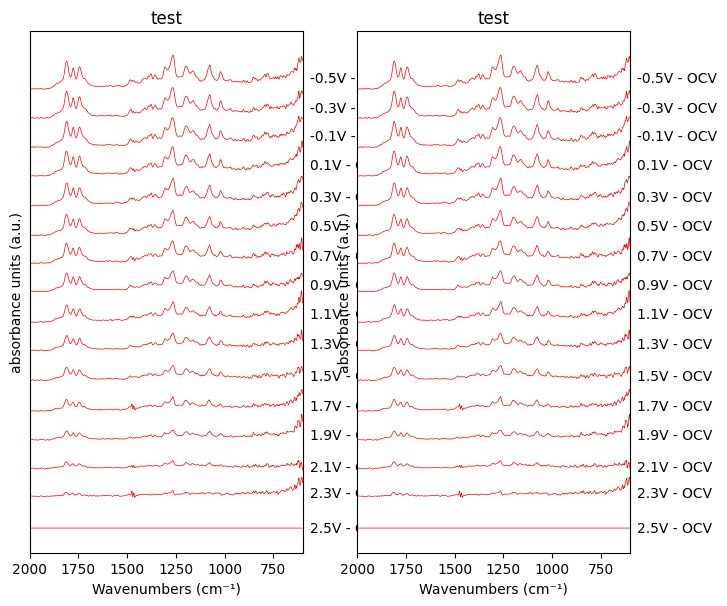

In [ ]:
fig, axs = plt.subplots(1,2)
oc.plot_differentials("OCV", "test", ax = axs[0], _xlim = (2000, 600), _offset = 0.005, _xytext = (25,-3))
oc.plot_differentials("OCV", "test", ax = axs[1], _xlim = (2000, 600), _offset = 0.005, _xytext = (25,-3))


In [ ]:
_background = "OCV"
ttl = "Title"
_xlim = (2500,600)
_offset = 0.01,
_lw = 0.5
_color = "r"
_w, _h, _dpi = 7.75, 6.77, 100,
_xytext = (50,0)
plt.rcParams["figure.figsize"]  = (_w, _h)
fig = plt.figure(dpi = _dpi)
ax = fig.add_axes([0.5,0.1,0.4,0.8])
for i, k in enumerate(oc.dDiff.keys()):
  _y = oc.dDiff[k]-oc.dDiff[k][0] + i * _offset
  ax.plot(oc.x, _y, linewidth = _lw, color = _color)
  ax.annotate(
  f"{k} - {_background}",
  xy=(oc.x[len(oc.x)-100], _y[len(oc.x)-100]),
  xytext= _xytext,
  textcoords="offset points")


  ax.set_xlim(*_xlim)
  ax.set_xlabel("Wavenumbers (cm⁻¹)")
  ax.set_ylabel("absorbance units (a.u.)")
  ax.set_yticks([])
  ax.set_title(ttl)

In [ ]:
oc.dfDiff

,Wavenumbers/cm⁻¹,t0,2.5V - t0,2.4V - t0,2.3V - t0,2.2V - t0,2.1V - t0,2.0V - t0,1.9V - t0,1.8V - t0,...,0.4V - t0,0.3V - t0,0.2V - t0,0.1V - t0,0.0V - t0,-0.1V - t0,-0.2V - t0,-0.3V - t0,-0.4V - t0,-0.5V - t0
0,3997.408331,0.035018,0.0,0.001325,0.001927,0.001883,0.002649,0.002855,0.003299,0.004079,...,0.008948,0.009517,0.009763,0.010179,0.010310,0.010973,0.010916,0.011463,0.011478,0.011462
1,3995.983738,0.034870,0.0,0.001408,0.001942,0.002022,0.002857,0.002936,0.003451,0.004155,...,0.009105,0.009557,0.009897,0.010283,0.010494,0.011102,0.011081,0.011578,0.011646,0.011595
2,3994.559145,0.034931,0.0,0.001348,0.001806,0.002032,0.002878,0.002823,0.003448,0.004112,...,0.009162,0.009484,0.009869,0.010290,0.010571,0.011079,0.011116,0.011500,0.011738,0.011587
3,3993.134552,0.035078,0.0,0.001198,0.001605,0.001940,0.002752,0.002676,0.003359,0.004001,...,0.009160,0.009401,0.009784,0.010241,0.010588,0.010938,0.011039,0.011345,0.011747,0.011512
4,3991.709958,0.035205,0.0,0.000994,0.001435,0.001812,0.002590,0.002653,0.003284,0.003917,...,0.009122,0.009389,0.009709,0.010189,0.010577,0.010793,0.010905,0.011242,0.011699,0.011408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2381,605.452081,-0.001757,0.0,0.001584,0.001158,0.000724,0.002964,0.001867,0.002894,0.003808,...,0.010707,0.010044,0.011363,0.011419,0.012408,0.011652,0.010756,0.013519,0.014669,0.012430
2382,604.027488,-0.001653,0.0,0.001210,0.000185,0.000420,0.002245,0.001606,0.002668,0.002794,...,0.010099,0.009579,0.010936,0.010613,0.011570,0.010791,0.010327,0.012950,0.014125,0.011969
2383,602.602895,-0.001473,0.0,0.001085,-0.000711,-0.000022,0.001603,0.001513,0.002348,0.002117,...,0.009186,0.008827,0.010561,0.009711,0.010997,0.010059,0.009947,0.012379,0.013410,0.011526
2384,601.178302,-0.001587,0.0,0.001043,-0.001316,-0.000365,0.001613,0.001545,0.002460,0.002158,...,0.008395,0.008039,0.010479,0.009113,0.011042,0.009736,0.009909,0.012339,0.012964,0.011329


In [ ]:
clean_colab_content(preserve_csv = True)

⚠️  This will delete most files in /content/. Google Drive and .csv files will be preserved. Proceed? (y/n): y
✅ Cleanup complete.
🗑️  Deleted: 2002 items
⏭️  Skipped: 4 items
📁 Preserved files/directories:
  - /content/260308-5-NaCl_2_Cu_mesh-NaFSI_13C_EC_DEC-1_4p5_4p5_65deg_64scans_7p5kHz_tir.csv
  - /content/260308-LSV1p1-5-NaCl_2_Cu_mesh-NaFSI_13C_EC_DEC-1_4p5_4p5_65deg_64scans_7p5kHz_selected.csv
  - /content/260308-5-NaCl_2_Cu_mesh-NaFSI_13C_EC_DEC-1_4p5_4p5_65deg_64scans_7p5kHz_all.csv
  - /content/260308-5-NaCl_2_Cu_mesh-NaFSI_13C_EC_DEC-1_4p5_4p5_65deg_64scans_7p5kHz_timestamped.csv


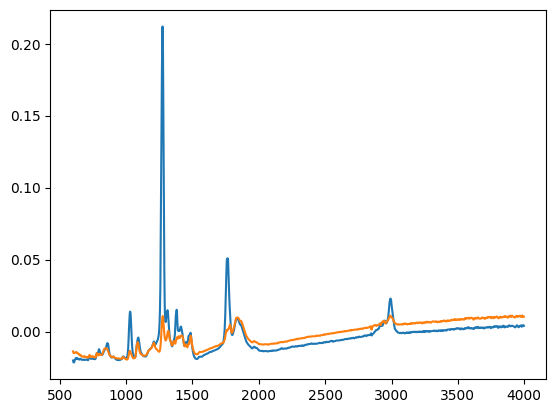

In [ ]:
y1 = oc.d["Sample 0"]["AB"]
y2 = oc.d["Sample 63"]["AB"]
plt.plot(oc.x,y1)
plt.plot(oc.x,y2)

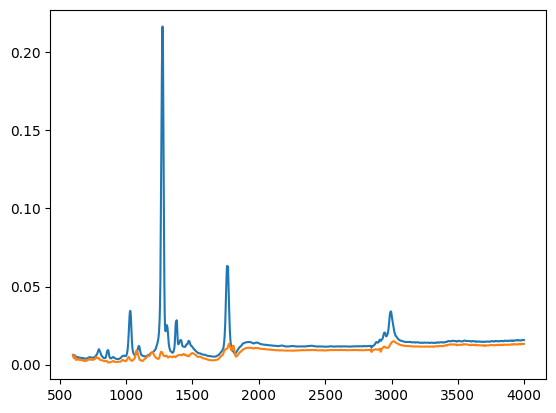

In [ ]:
y1 = oc.d["Sample 0"]["AB"]
y2 = oc.d["Sample 63"]["AB"]
plt.plot(oc.x,y1)
plt.plot(oc.x,y2)


In [ ]:
def pointSlope(x1, x2, y1, y2):
  m = (y2-y1)/(x2-x1)
  y = m * (oc.x - x1) + y1
  return y

In [ ]:
def flatten(x1, x2, y):
  ub1 = x1 + 1
  lb1 = x1 - 1
  ub2 = x2 + 1
  lb2 = x2 - 1

  for i in enumerate(oc.x):
    if (i[1] < ub1) and (i[1] > lb1):
      index1 = i[0]
      # print(index1)
      break

  for i in enumerate(oc.x):
    if (i[1] < ub2) and (i[1] > lb2):
      index2 = i[0]
      break

  baseline = pointSlope(oc.x[index1], oc.x[index2], y[index1], y[index2])

  return y - baseline

In [ ]:
oc.d["Sample 0"].keys()

dict_keys(['Text Information', 'Optik', 'Fourier Transformation', 'Acquisition', 'Sample', 'ScSm', 'AB', 'Instrument (Rf)', 'Optik (Rf)', 'Acquisition (Rf)', 'Fourier Transformation (Rf)', 'ScRf Data Parameter', 'ScRf', 'History', 'AB Data Parameter', 'ScSm Data Parameter', 'Instrument', 'Timestamp'])

(4000.0, 400.0)

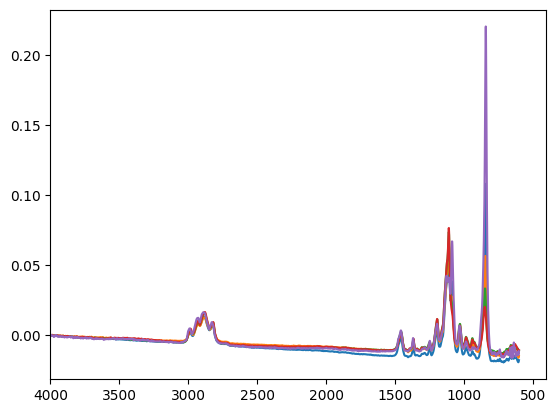

In [ ]:
l = [k for k in oc.d.keys()]
fig, ax = plt.subplots()
for k in l[1:6]:
  yShifted = oc.d[k]["AB"] - oc.d[k]["AB"][0]
  yFlattened = yShifted - pointSlope(oc.x[0], oc.x[1683], yShifted[0], yShifted[1683])
  ax.plot(oc.x,yShifted)
ax.set_xlim(4000,400)

In [ ]:
oc.rebase(background = list(oc.d.keys())[0])

Type the expt start point in EC-Lab time (seconds)	3936.366


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
for i in enumerate(oc.x):
  if (i[1] > 2240) and (i[1] < 2250):
    print(i)

(1227, np.float64(2249.4325569036864))
(1228, np.float64(2248.007963770752))
(1229, np.float64(2246.583370637817))
(1230, np.float64(2245.158777504883))
(1231, np.float64(2243.7341843719482))
(1232, np.float64(2242.3095912390136))
(1233, np.float64(2240.8849981060794))


In [ ]:
oc.shiftCorrection(referencePoint = 0)

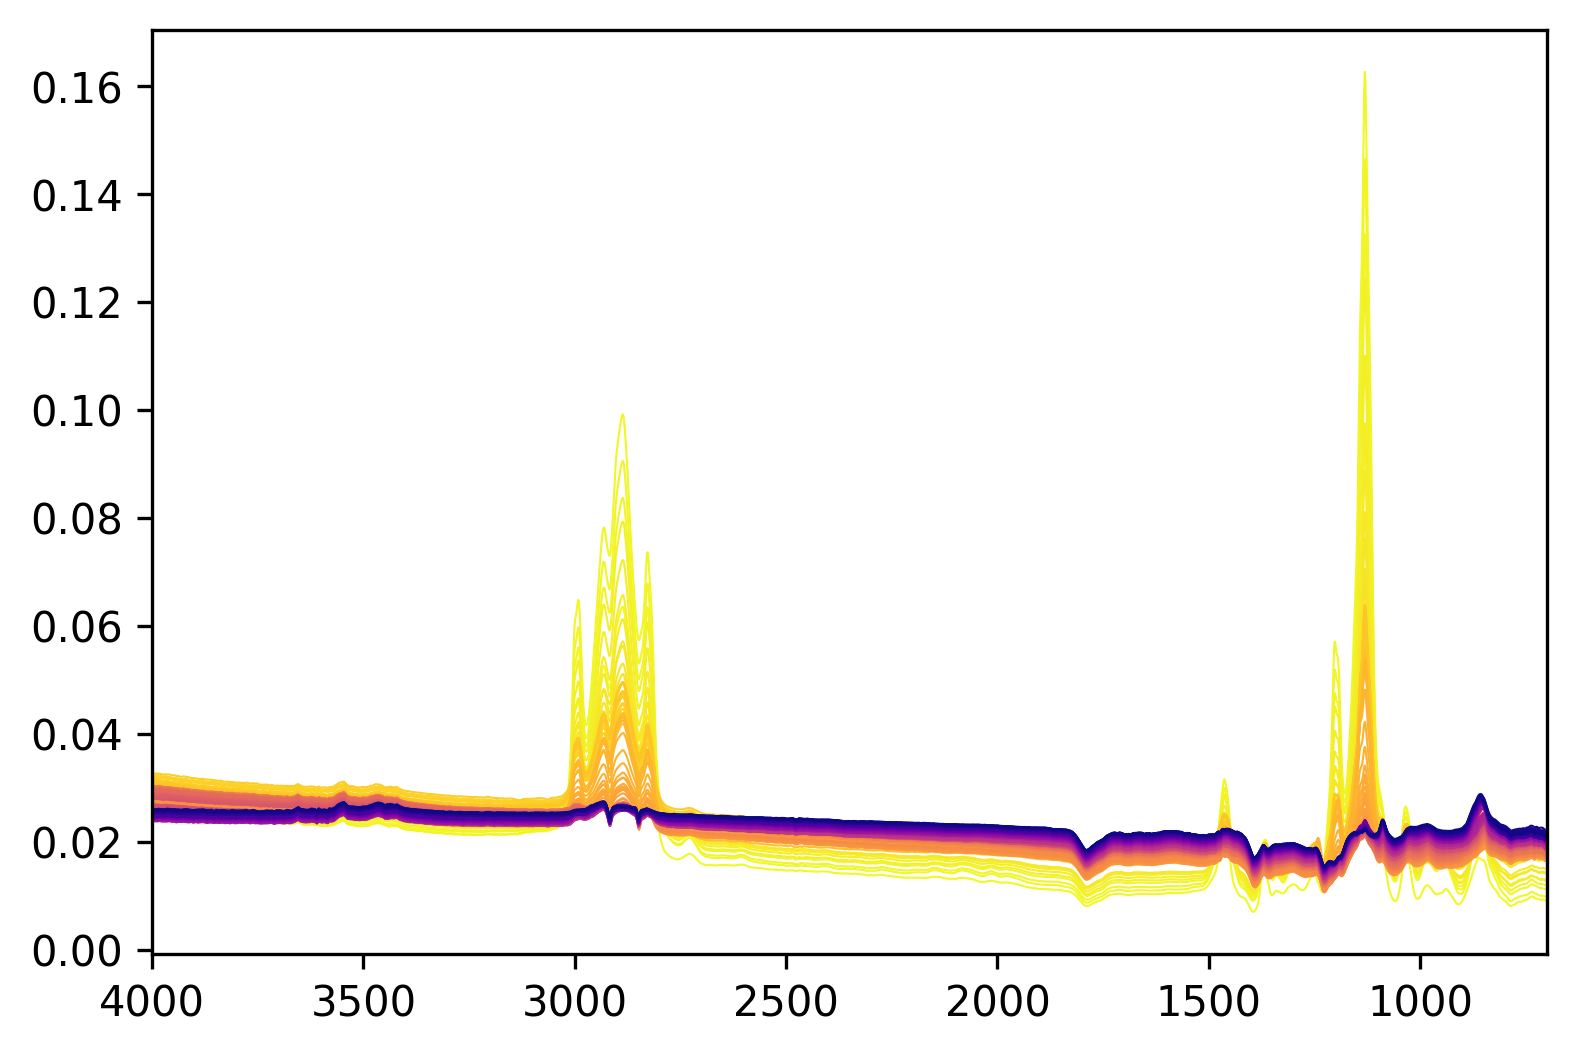

In [ ]:
plt.rcParams["figure.figsize"]  = (6,4)
cmap = plt.cm.plasma
cmap2 = plt.cm.plasma
center = 0
colors = cmap(np.linspace(0,1,center)).tolist() + cmap2(np.linspace(1,0,len(oc.d.keys())- center + 1)).tolist()
fig,ax = plt.subplots(dpi = 300)
for k,c in zip(oc.d.keys(),colors):
  ax.plot(oc.x, oc.d[k]["AB"], color = c, linewidth = 0.5)

ax.set_xlim(4000,700)
fig.show()

In [ ]:
# plt.plot(oc.x[::-1], np.interp(oc.x[::-1], [oc.x[-1], oc.x[1261], oc.x[0]], [oc.d["Sample 0"]["AB"][-1],oc.d["Sample 0"]["AB"][1261],oc.d["Sample 0"]["AB"][0]] ))

In [ ]:
len(list(oc.d.keys()))

235

In [ ]:
# plt.plot(oc.x, oc.d["Sample 0"]["AB"])
# plt.plot(oc.x, oc.d["Sample 1"]["AB"])
# plt.plot(oc.x, np.log(oc.d["Sample 0"]["ScSm"]/oc.d["Sample 1"]["ScSm"]))
# plt.plot(oc.x, oc.d["Sample 1"]["AB"] - oc.d["Sample 0"]["AB"])

In [ ]:
def rubberband(x,y, lowerCutoff):
  import numpy as np
  from scipy.spatial import ConvexHull
  arr = np.array([x[:len(x) - lowerCutoff], y[:len(x) - lowerCutoff]]).T
  v = ConvexHull(arr).vertices
  print(v)
  v = np.roll(v, -v.argmin())
  print(v)
  v = v[:v.argmax()+1]
  print(v)
  # baseline = np.interp(x, x[v], y[v])
  return v

In [ ]:
baselines = {}
subtractedSpectra = {}
for k in [i for i in oc.d.keys()][0:1]:
  baselines[k] = rubberband(oc.x, oc.d[k]["AB"], 0)
  # subtractedSpectra[k] = oc.d[k]["AB"] - baselines[k]

[2385    0    7  761 1483 1486 1843 1939 1968 2094 2290 2361 2375 2376
 2382 2383 2384]
[   0    7  761 1483 1486 1843 1939 1968 2094 2290 2361 2375 2376 2382
 2383 2384 2385]
[   0    7  761 1483 1486 1843 1939 1968 2094 2290 2361 2375 2376 2382
 2383 2384 2385]


(4500.0, 400.0)

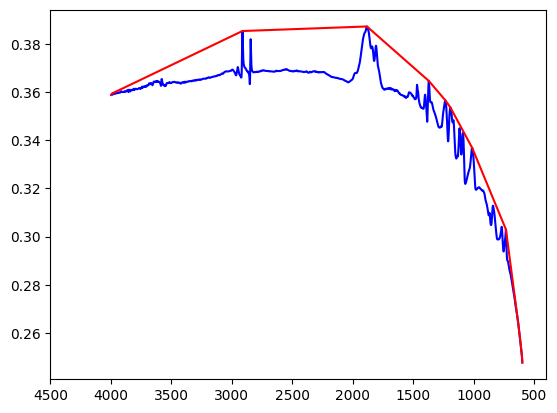

In [ ]:
fig,ax = plt.subplots()
offset = 0
for k in baselines.keys():
  ax.plot(oc.x, oc.d[k]["AB"], "b")
  ax.plot(oc.x[baselines[k]], oc.d[k]["AB"][baselines[k]], "r")
  offset += 0.1

ax.set_xlim(4500,400)

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull

In [ ]:
arr = np.array([oc.x,oc.d["Sample 0"]["AB"]]).T

In [ ]:
v = ConvexHull(arr).vertices
v

array([   0, 1431, 1432, 1918, 1919, 2291, 2349, 2350, 2360, 2368, 2374,
       2382, 2383, 2384, 2385,   20,    8], dtype=int32)

In [ ]:
v = np.roll(v,-v.argmin())
print(v)
v = v[v.argmax():]
print(v)
baseline = np.interp(oc.x, oc.x[v], oc.d["Sample 0"]["AB"][v])


[   0 1431 1432 1918 1919 2291 2349 2350 2360 2368 2374 2382 2383 2384
 2385   20    8]
[2385   20    8]


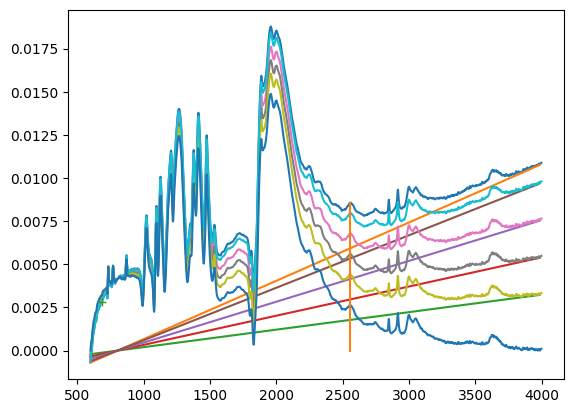

In [ ]:
point_picker = 60

fig, ax = plt.subplots()
ax.plot(oc.x, oc.d["Sample 0"]["AB"])
ax.plot(oc.x[v], oc.d["Sample 0"]["AB"][v])
ax.plot(oc.x[v], baseline[v]*0.3)
ax.plot(oc.x[v], baseline[v]*0.5)
ax.plot(oc.x[v], baseline[v]*0.7)
ax.plot(oc.x[v], baseline[v]*0.9)
# ax.plot(oc.x[v], baseline[v])
ax.plot(oc.x, (oc.d["Sample 0"]["AB"] - baseline*0.3))
ax.plot(oc.x, (oc.d["Sample 0"]["AB"] - baseline*0.5))
ax.plot(oc.x, (oc.d["Sample 0"]["AB"] - baseline*0.7))
ax.plot(oc.x, (oc.d["Sample 0"]["AB"] - baseline*0.1))
ax.plot(oc.x, (oc.d["Sample 0"]["AB"] - baseline))
ax.plot([oc.x[1015]]*2, [0, oc.d['Sample 0']["AB"][1015]])
ax.plot(oc.x[2386-point_picker], oc.d["Sample 0"]["AB"][2386 - point_picker], "+")


In [ ]:
test = rubberband(oc.x, oc.d["Sample 1"]["AB"])

In [ ]:
oc.t_stamp()

Type the expt start point in EC-Lab time (seconds)	123


In [ ]:
oc.df()

In [ ]:
oc.dfAB

,Wavenumbers/cm⁻¹,Sample 0,Sample 1
0,3997.408331,0.010883,0.017010
1,3995.983738,0.010877,0.017038
2,3994.559145,0.010875,0.017048
3,3993.134552,0.010871,0.017036
4,3991.709958,0.010861,0.017015
...,...,...,...
2381,605.452081,-0.000136,0.002249
2382,604.027488,-0.000224,0.002198
2383,602.602895,-0.000347,0.002036
2384,601.178302,-0.000502,0.001842


[   0 1431 1432 1918 1919 2291 2325 1522  104   20    8]
[   0 1431 1432 1918 1919 2291 2325 1522  104   20    8]
[2325 1522  104   20    8]


(4000.0, 700.0)

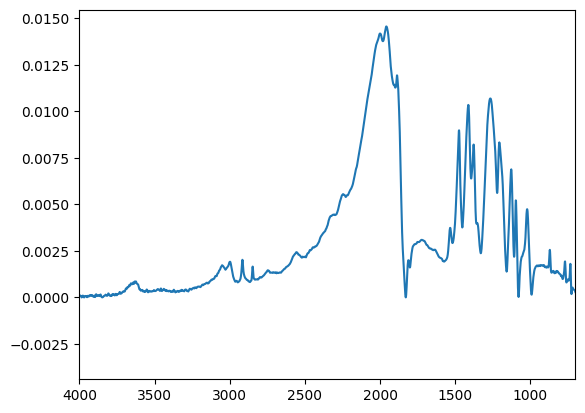

In [ ]:
arr = np.array([oc.x[0:2386-point_picker],oc.d["Sample 0"]["AB"][0:2386 - point_picker]]).T
v = ConvexHull(arr).vertices
print(v)
v = np.roll(v,v.argmin())
print(v)
v = v[v.argmax():]
print(v)
baseline = np.interp(oc.x, oc.x[v], oc.d['Sample 0']["AB"][v])
fig, ax = plt.subplots()

ax.plot(oc.x, oc.d["Sample 0"]["AB"]- baseline)
ax.set_xlim()

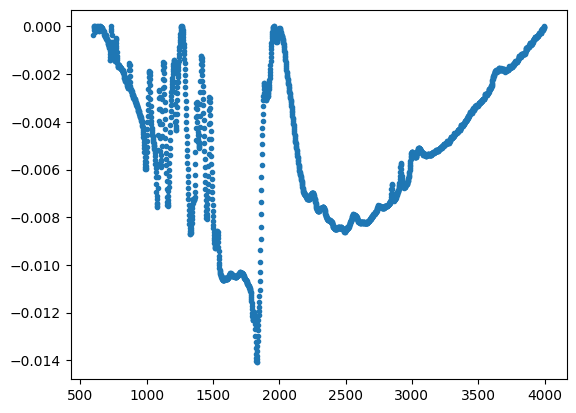

In [ ]:
baseline = np.interp(oc.x, oc.x[v], oc.d['Sample 0']["AB"][v])
baseline.shape

fig, ax = plt.subplots()

ax.plot(oc.x, oc.d["Sample 0"]["AB"]-baseline, ".")


In [ ]:
import numpy as np
from scipy.spatial import ConvexHull

def rubberband(x, y):
    # Find the convex hull
    v = ConvexHull(np.array([[x], [y]])).vertices
    # Rotate convex hull vertices until they start from the lowest one
    v = np.roll(v, -v.argmin())
    # Leave only the ascending part
    v = v[:v.argmax()]

    # Create baseline using linear interpolation between vertices
    return np.interp(x, x[v], y[v])

In [ ]:
baseline = rubberband(oc.x, oc.d["Sample 0"]["AB"])

In [ ]:
oc.d["Sample 0"]["AB"]

NameError: name 'oc' is not defined

In [ ]:
# for i in oc.x:
#   print(round(i))

In [ ]:
round(1.15454,1)

1.2

In [ ]:
def sampleNoise(highWN , lowWN, sample):
  sampledRangeidx = []
  sampledX = []
  for i in enumerate(oc.x):
    if (round(i[1]) < highWN) and (round(i[1]) > lowWN):
      sampledRangeidx.append(i[0]) #grabs corresponding indices from the full range for use
      sampledX.append(i[1]) #grabs x range corresponding to filters
    else:
      pass

  noise = np.array([oc.d[sample]["AB"][i] for i in sampledRangeidx])
  # plt.plot(oc.x[sampledRangeidx[0]:sampledRangeidx[-1]+1], noise)

  # noiseFlattened = flatten(sampledX[0], sampledX[-1], oc.d[sample]["AB"]) #flattens the noise from the min and maximum sampled X values of the range
  # noiseFlattened = noiseFlattened[sampledRangeidx[0]:sampledRangeidx[-1]+1]

  # plt.plot(sampledX, noiseFlattened)

  avgNoise = np.average(noise)
  residuals = noise - avgNoise
  mse = np.average(residuals**2)
  rmse = np.sqrt(mse)

  # plt.plot(sampledX,residuals)

  # print(rmse)
  return rmse
sampleNoise(2000, 600, "Sample 0")

np.float64(0.003925241430294939)

In [ ]:
def shiftIdx(l, shift):
  overflow = len(l)
  shift = shift%overflow
  l = np.array(l)
  l = (l - shift) % overflow
  return l.tolist()

shiftIdx([1,2,3,4,5],4)

[2, 3, 4, 0, 1]

In [ ]:
test = [0,1,2,3]
test[0: len([0,1,2,3])]


[0, 1, 2, 3]

In [ ]:
def joinShiftSplit(shift, *args):
  _l = []
  anchor = []
  out = []

  for i in args:
    _l = _l + i
    anchor.append(len(_l))

  _l = shiftIdx(_l, shift)

  for i in range(len(anchor)):
    if i == 0:
      out.append(_l[0:anchor[i]])
    else:
      out.append(_l[anchor[i-1]:anchor[i]])


  return out
joinShiftSplit(2,[0,1,2,3],[4,5,6,7])

[4, 8]


[[6, 7, 0, 1], [2, 3, 4, 5]]

Data set Size: 2386
Bin Size: 48 points
Remainder: 34


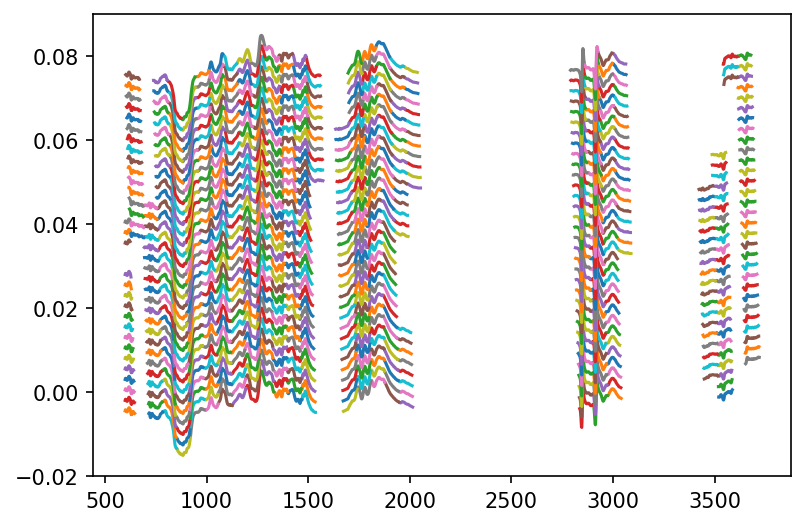

In [ ]:
plt.rcParams["figure.figsize"]  = (6,4)
def findPeaks(bins, sample, referenceNoise, sensitivityFactor = 1):
  #The higher the sensitivity factor, the more things get classified as 'noise'

  datasetSize = len(oc.d[sample]["AB"])
  binSize = datasetSize//(bins - 1)

  print("Data set Size:", datasetSize)
  print(f"Bin Size: {binSize} points")

  remainder = datasetSize % (bins - 1)
  print("Remainder:", remainder)


  binSets = {}
  for k in range(0,remainder-1):
    binLookup = []

    for i in range(0, bins - 1):
      bindices = [j + k + binSize * i for j in range(0,binSize)] #list of indices for a given binSize
      binLookup.append(bindices)
    binLookup.append([i + 1 + binLookup[-1][-1] for i in range(0,remainder - k)])
    binSets[f"Bin Set {k}"] = binLookup #appends a shifted set of bins to a unique dictionary.

  # for k in binSets.keys():
  #   print(f"{k}:")
  #   print(binSets[k][0])
  #   print(binSets[k][-1])



  #Handle special case

  # print(referenceNoise)

  # print(binLookup[1:-1])
  # shuffleBins = joinShiftSplit(1,*binLookup[1:-1])
  # print(shuffleBins)
  dLabels = {}
  for i in range(len(binLookup)):
    dLabels[f"Bin {i}"] = []

  try:
    fig, ax = plt.subplots(dpi = 150)
    increment = 0
    for k in binSets.keys():
      counter = 0

      for i in binSets[k]: #for a given set of Bins
        test = sampleNoise(oc.x[i[0]], oc.x[i[-1]], sample) #Sample the average noise of the bin.

        if test > referenceNoise * sensitivityFactor: #if the bin has an average noise which is greater than a reference noise value
          ax.plot(oc.x[i[0]:i[-1]+1], oc.d[sample]["AB"][i[0]:i[-1]+1]+ increment * 0.0025) #plot it as Data, and label the bin as a Data bin
          dLabels[f"Bin {counter}"].append("Data")

        # else:
        #   ax.plot(oc.x[i[0]:i[-1]+1], oc.d[sample]["AB"][i[0]:i[-1]+1]+ increment * 0.0025 ,"r")
        #   dLabels[f"Bin {counter}"].append("Noise")
        counter += 1
      increment += 1

    for k in dLabels.keys():
      if ("Noise" in dLabels[k]) and ("Data" in dLabels[k]):
        print(f"{k}:",dLabels[k])

  except IndexError:
    print("too many bins for adequate sampling, halving bin count...")
    bins /= 2
    bins = int(bins)
    print(f"New bin count: {bins}")
    findPeaks(bins, sample, referenceNoise, sensitivityFactor)
  pass
noisyBits = np.average([sampleNoise(2745, 2184, "Sample 0"), sampleNoise(3990, 3600, "Sample 0"), sampleNoise(800, 600,"Sample 0")])
findPeaks(50, "Sample 1", referenceNoise = sampleNoise(2745, 2184, "Sample 0"), sensitivityFactor = 1)

Reflections on above: We wrote a function which bins portions of a given spectrum, evaluates the average noise level of that section, and compares it against a reference value from a "representative" section of the spectrum (as evaluated by the user), now if we change the input feed in of the function to allow us to just feed a generic sample set (like differentials), we should be able to try to distinguish peaks from just random fluctuations.

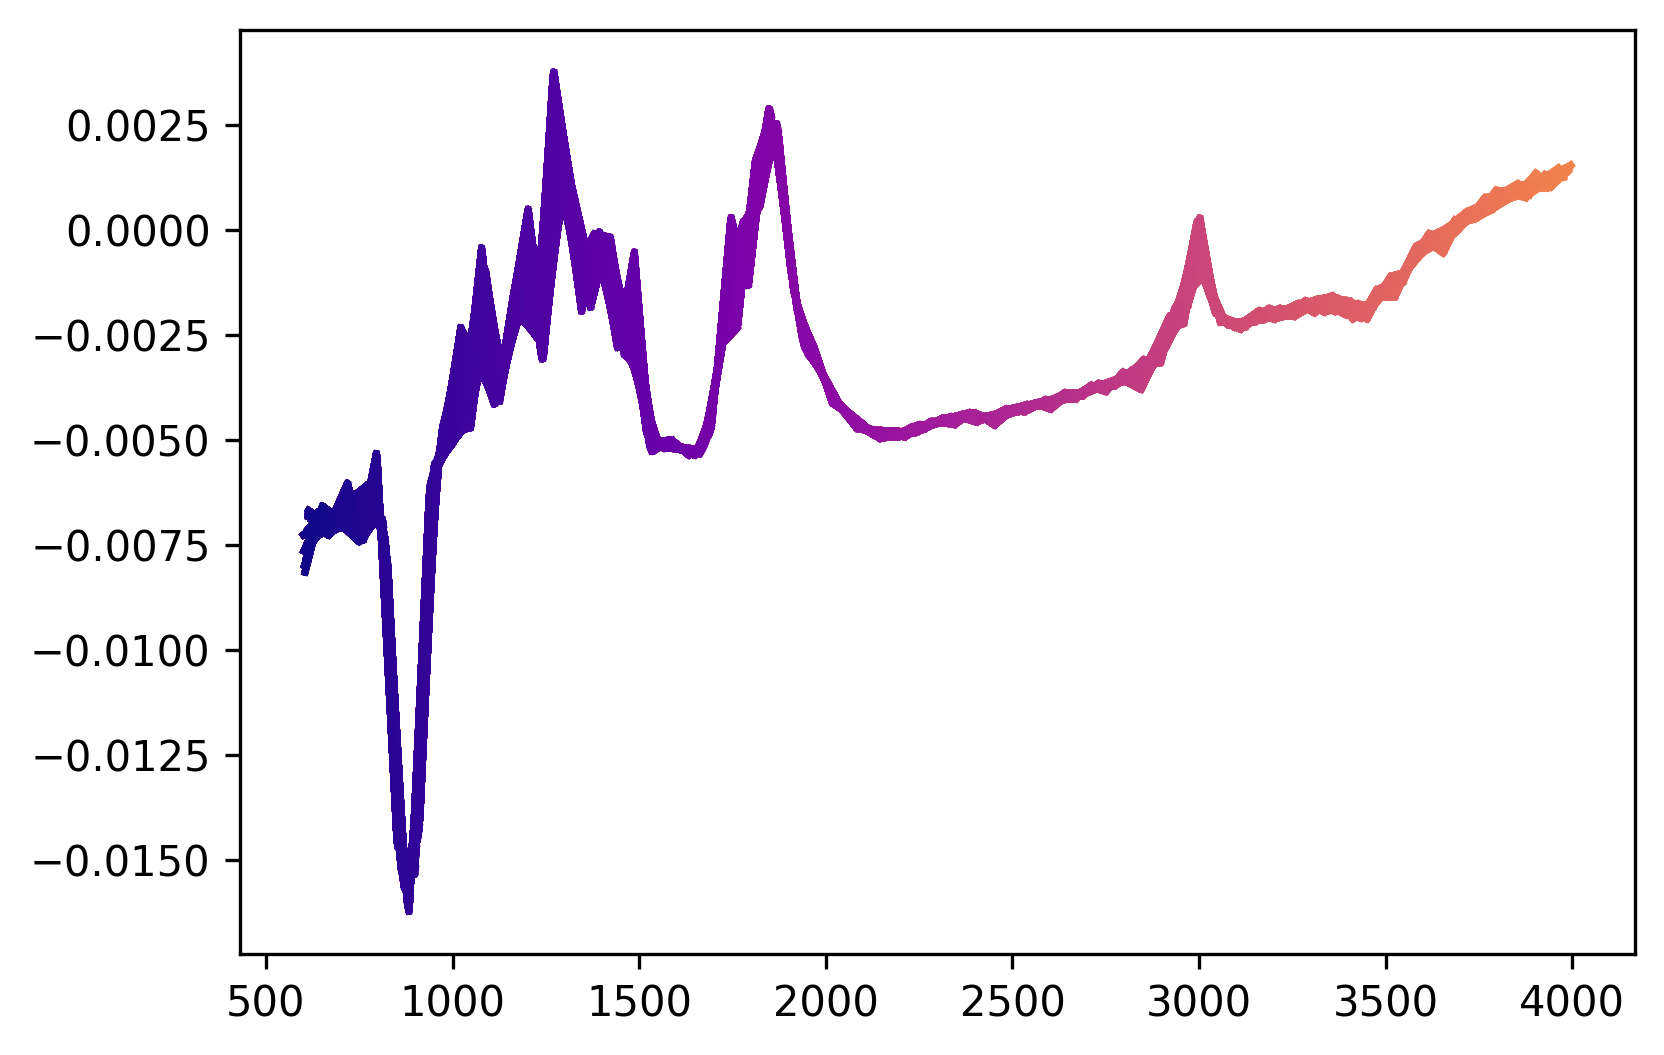

In [ ]:
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.7,0,len(oc.x))).tolist()
fig, ax = plt.subplots(dpi = 300)
for i, c in zip(range(0,len(oc.x)),colors):
  plt.plot(oc.x[i::30], oc.d["Sample 0"]["AB"][i::30], color = c)
